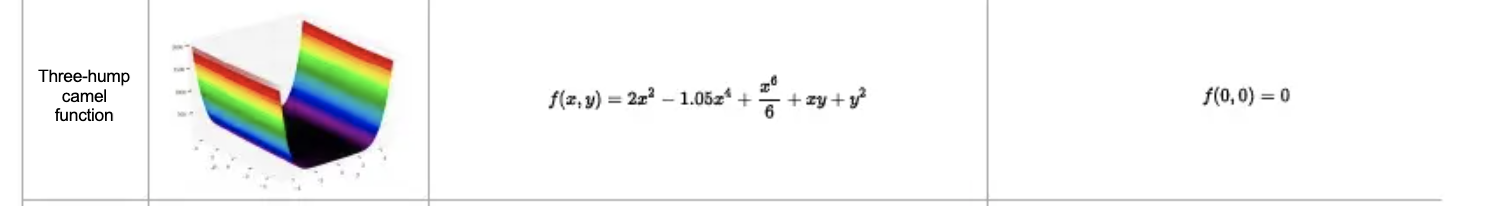

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from IPython import display
import time

In [18]:
POP_SIZE = 120
GENERATIONS = 120
mut = 0.07
ELITE_COUNT = 6

RANGE_X, RANGE_Y = [-5, 5], [-5, 5]
limit = 8
LOCAL_STEP_SCALE = 0.06

np.random.seed(42)

population = np.random.uniform(low=[RANGE_X[0], RANGE_Y[0]],
                               high=[RANGE_X[1], RANGE_Y[1]],
                               size=(POP_SIZE, 2))

def three_hump_camel(x, y):
    return 2*x**2 - 1.05*x**4 + (x**6)/6 + x*y + y**2

def fitness_from_vals(vals):
    return -vals

def select(pop, fit_vals, k):
    shifted = fit_vals - np.min(fit_vals) + 1e-12
    probs = shifted / np.sum(shifted)
    idx = np.random.choice(np.arange(len(pop)), size=k, replace=True, p=probs)
    return pop[idx]

def crossover(a, b):
    alpha = np.random.rand()
    child = alpha * a + (1 - alpha) * b
    child += np.random.normal(0, 0.08, 2) * (1 - alpha) 
    return np.clip(child, [RANGE_X[0], RANGE_Y[0]], [RANGE_X[1], RANGE_Y[1]])

def mutate(ind, rate):
    if np.random.rand() < rate:
        ind += np.random.normal(0, 0.35, 2)
    return np.clip(ind, [RANGE_X[0], RANGE_Y[0]], [RANGE_X[1], RANGE_Y[1]])

In [19]:
fitness_history = []
change_behavior = 0
best_so_far = np.inf

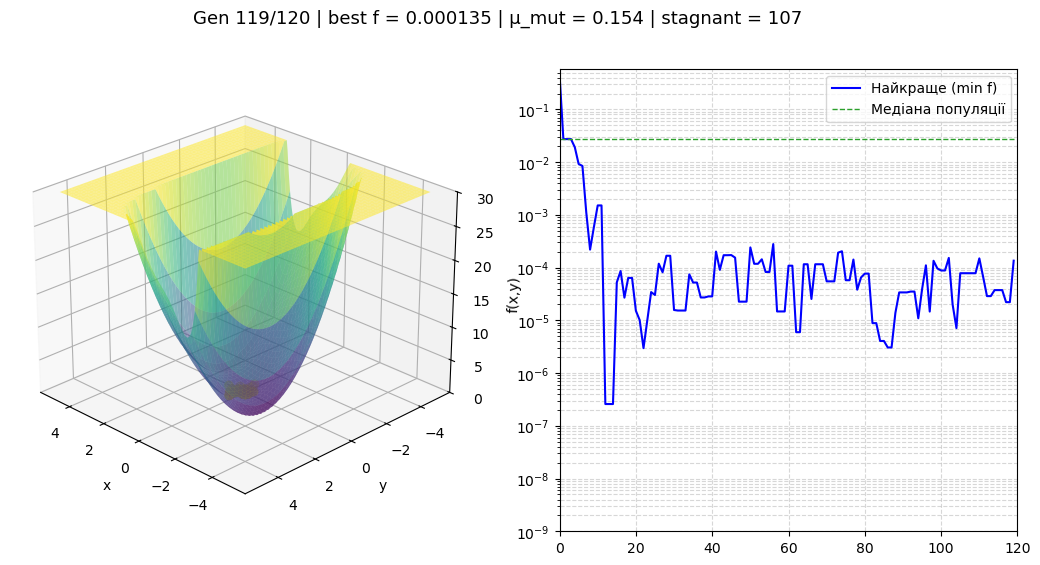

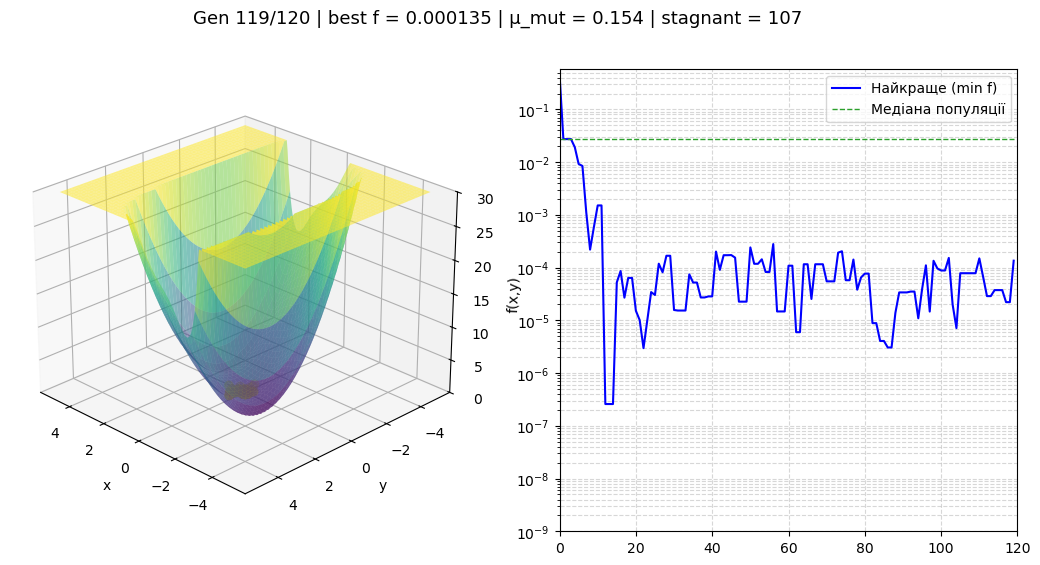

In [20]:
x_vals = np.linspace(RANGE_X[0], RANGE_X[1], 200)
y_vals = np.linspace(RANGE_Y[0], RANGE_Y[1], 200)
X, Y = np.meshgrid(x_vals, y_vals)
Z = three_hump_camel(X, Y)

fig = plt.figure(figsize=(13, 6))
ax3d = fig.add_subplot(121, projection='3d')
ax2d = fig.add_subplot(122)

ax3d.plot_surface(X, Y, np.clip(Z, 0, 30), cmap=cm.viridis, alpha=0.55)
pop_scatter = ax3d.scatter([], [], [], c='orange', s=36)
best_scatter = ax3d.scatter([], [], [], c='red', s=90, marker='*')
ax3d.set_xlabel('x'); ax3d.set_ylabel('y'); ax3d.set_zlabel('f(x,y)')
ax3d.view_init(elev=25, azim=135)
ax3d.set_zlim(0, 30)

line_best, = ax2d.plot([], [], color='blue', lw=1.5, label='Найкраще (min f)')
line_median, = ax2d.plot([], [], color='tab:green', linestyle='--', lw=1, label='Медіана популяції')
ax2d.axhline(0, color='red', linestyle=':', linewidth=1)
ax2d.set_yscale('log')
ax2d.set_xlim(0, GENERATIONS)
ax2d.grid(True, which='both', ls='--', alpha=0.5)
ax2d.legend()

for gen in range(GENERATIONS):
    vals = np.array([three_hump_camel(p[0], p[1]) for p in population])
    fits = fitness_from_vals(vals)
    best_idx = np.argmin(vals)
    best_val = vals[best_idx]
    median_val = np.median(vals)
    fitness_history.append(best_val)

    if best_val < best_so_far - 1e-9:
        best_so_far = best_val
        change_behavior = 0
    else:
        change_behavior += 1

    adapt_mut = mut * (1 + 1.2 * min(change_behavior / limit, 1.0))
    adapt_mut = min(adapt_mut, 0.5)

    top_n = 10
    top_idx = np.argsort(vals)[:top_n]
    elite_idx = np.random.choice(top_idx, ELITE_COUNT, replace=False)

    elites = population[elite_idx].copy()

    parents = select(population, fits, POP_SIZE)

    children = []
    for i in range(0, POP_SIZE, 2):
        p1 = parents[i]
        p2 = parents[(i+1) % POP_SIZE]
        c1 = mutate(crossover(p1, p2), adapt_mut)
        c2 = mutate(crossover(p2, p1), adapt_mut)
        children.append(c1); children.append(c2)

    population = np.array(children)

    for i in range(ELITE_COUNT):
        if np.random.rand() < 0.07:
            elites[i] = mutate(elites[i], adapt_mut)
    population[-ELITE_COUNT:] = elites

    local_improve = population[best_idx] + np.random.normal(0, LOCAL_STEP_SCALE * (1 + change_behavior/ (limit+1)), 2)
    local_improve = np.clip(local_improve, [RANGE_X[0], RANGE_Y[0]], [RANGE_X[1], RANGE_Y[1]])
    if three_hump_camel(local_improve[0], local_improve[1]) < three_hump_camel(population[best_idx][0], population[best_idx][1]):
        population[best_idx] = local_improve

    if gen % 3 == 0 or gen == GENERATIONS - 1:
        display.clear_output(wait=True)
        z_coords = three_hump_camel(population[:,0], population[:,1])
        pop_scatter._offsets3d = (population[:,0], population[:,1], z_coords)
        current_best_idx = np.argmin(z_coords)
        best_scatter._offsets3d = ([population[current_best_idx,0]], [population[current_best_idx,1]], [z_coords[current_best_idx]])
        color = cm.plasma(gen / max(GENERATIONS-1,1))
        pop_scatter.set_color([color])

        line_best.set_data(range(len(fitness_history)), fitness_history)
        med_line = [np.median([three_hump_camel(population[j,0], population[j,1]) for j in range(len(population[:]))[:len(fitness_history)]]) for _ in range(len(fitness_history))]
        line_median.set_data(range(len(fitness_history)), np.minimum.accumulate(np.full(len(fitness_history), median_val)))
        ax2d.set_ylim(max(min(fitness_history + [1e-9]), 1e-9), max(fitness_history) * 1.25)
        plt.suptitle(f"Gen {gen}/{GENERATIONS} | best f = {best_val:.6f} | μ_mut = {adapt_mut:.3f} | stagnant = {change_behavior}", fontsize=13)
        display.display(fig)
        time.sleep(0.06)
        
display.clear_output(wait=True)
final_vals = np.array([three_hump_camel(p[0], p[1]) for p in population])
final_best_idx = np.argmin(final_vals)
best_point = population[final_best_idx]
best_value = final_vals[final_best_idx]

display.display(fig)

In [21]:
print(f"x = {best_point[0]:.9f}")
print(f"y = {best_point[1]:.9f}")
print(f"f(x*, y*) = {best_value:.9f}")

x = -0.007138798
y = -0.003219771
f(x*, y*) = 0.000135274
